🤖 Machine Learning &nbsp;·&nbsp; *Bài 9/23*

[« Machine Learning - Linear Regression](008_ml_linear_regression.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - Multiple Regression »](010_ml_multiple_regression.ipynb)

# Machine Learning - Polynomial Regression

> 📖 **Học song song trên W3Schools:** [python_ml_polynomial_regression.asp](https://www.w3schools.com/python/python_ml_polynomial_regression.asp)
>
> 🎯 **Trong bài này:** Polynomial Regression · How Does it Work? · Example Explained · R-Squared · Predict Future Values · Bad Fit?

## Polynomial Regression — Hồi quy đa thức

Nếu các điểm dữ liệu **không** phù hợp với hồi quy tuyến tính (đường thẳng), **hồi quy đa thức** có thể là lựa chọn lý tưởng.

Hồi quy đa thức, giống hồi quy tuyến tính, dùng mối quan hệ giữa x và y để tìm cách tốt nhất vẽ **một đường (cong)** đi qua các điểm dữ liệu.

## How Does it Work? — Hoạt động thế nào?

Ví dụ: ghi nhận 18 xe đi qua một trạm thu phí — tốc độ của xe (y) và **giờ trong ngày** (x) khi xe đi qua:

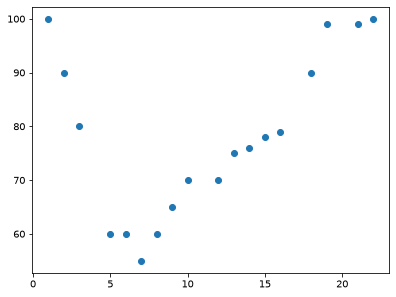

In [1]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 18, 19, 21, 22]
y = [100, 90, 80, 60, 60, 55, 60, 65, 70, 70, 75, 76, 78, 79, 90, 99, 99, 100]

plt.scatter(x, y)
plt.show()

Import `numpy` và vẽ đường hồi quy đa thức:

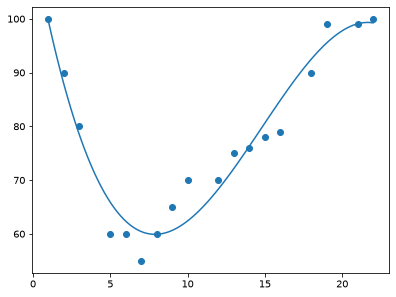

In [2]:
import numpy
import matplotlib.pyplot as plt

x = [1, 2, 3, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 18, 19, 21, 22]
y = [100, 90, 80, 60, 60, 55, 60, 65, 70, 70, 75, 76, 78, 79, 90, 99, 99, 100]

mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

myline = numpy.linspace(1, 22, 100)

plt.scatter(x, y)
plt.plot(myline, mymodel(myline))
plt.show()

## Example Explained — Giải thích

- `numpy.polyfit(x, y, 3)` tìm hệ số của đa thức **bậc 3** phù hợp nhất với dữ liệu; `numpy.poly1d(...)` biến các hệ số thành một **hàm** đa thức.
- `numpy.linspace(1, 22, 100)` tạo 100 điểm cách đều từ 1 đến 22 để vẽ đường cong mượt.
- Vẽ scatter gốc và đường hồi quy.

## R-Squared

Cần biết mối quan hệ giữa x và y tốt tới mức nào — nếu không có quan hệ, hồi quy đa thức không dự đoán được gì.

Mức độ phù hợp đo bằng **R-squared**, trong khoảng **0 đến 1**: 0 là không quan hệ, 1 là quan hệ 100%.

Module **scikit-learn** (`sklearn`) có hàm `r2_score()` tính giá trị này:

In [3]:
import numpy
from sklearn.metrics import r2_score

x = [1, 2, 3, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 18, 19, 21, 22]
y = [100, 90, 80, 60, 60, 55, 60, 65, 70, 70, 75, 76, 78, 79, 90, 99, 99, 100]

mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

print(r2_score(y, mymodel(x)))

0.9432150416451026


> 📌 Kết quả **0.94** cho thấy quan hệ rất tốt — có thể dùng hồi quy đa thức để dự đoán.

## Predict Future Values — Dự đoán

Dự đoán tốc độ của xe đi qua trạm lúc **17 giờ**:

In [4]:
import numpy

x = [1, 2, 3, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 18, 19, 21, 22]
y = [100, 90, 80, 60, 60, 55, 60, 65, 70, 70, 75, 76, 78, 79, 90, 99, 99, 100]

mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

speed = mymodel(17)
print(speed)

88.87331269698001


Dự đoán khoảng **88.87** km/h.

## Bad Fit? — Không phù hợp?

R² = 0.009952707566680652


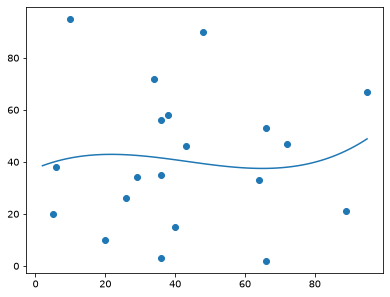

In [5]:
import numpy
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

x = [89, 43, 36, 36, 95, 10, 66, 34, 38, 20, 26, 29, 48, 64, 6, 5, 36, 66, 72, 40]
y = [21, 46, 3, 35, 67, 95, 53, 72, 58, 10, 26, 34, 90, 33, 38, 20, 56, 2, 47, 15]

mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))
myline = numpy.linspace(2, 95, 100)

plt.scatter(x, y)
plt.plot(myline, mymodel(myline))
plt.show()

print("R² =", r2_score(y, mymodel(x)))

R² rất thấp → dữ liệu **không** phù hợp với hồi quy đa thức.

---

## 🧠 Ghi nhớ nhanh

> - Hồi quy đa thức: đường **cong** qua dữ liệu — `numpy.poly1d(numpy.polyfit(x, y, bậc))`.
> - Đánh giá bằng **R²** (0 → 1): `sklearn.metrics.r2_score(y, model(x))`.
> - Dự đoán: `model(giá_trị_x_mới)`.

---

## 📝 Exercise — Bài tập nhanh

**❓ Câu hỏi:** Hàm nào tính **R-squared** trong scikit-learn?

- **A.** `sklearn.r2()`
- **B.** `sklearn.metrics.r2_score()`
- **C.** `numpy.r2_score()`
- **D.** `scipy.stats.r2()`

<details>
<summary>👉 Xem đáp án</summary>

✅ **Đáp án: B** — `sklearn.metrics.r2_score()`

</details>

---

[« Machine Learning - Linear Regression](008_ml_linear_regression.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - Multiple Regression »](010_ml_multiple_regression.ipynb)